In [69]:
!pip install keras tensorflow tf2onnx onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 98.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [37]:
from keras.datasets.mnist import load_data
import tensorflow as tf
import matplotlib.pyplot as plt

In [38]:
mnist = tf.keras.datasets.mnist

In [39]:
(training_images, training_labels), (test_images, test_labels) = load_data()

In [40]:
print(f'Imágenes de training: {len(training_images)} con un tamaño de {training_images[0].shape}')
print(f'Imágenes de test: {len(test_images)} con un tamaño de {training_images[0].shape}')

Imágenes de training: 60000 con un tamaño de (28, 28)
Imágenes de test: 10000 con un tamaño de (28, 28)


In [41]:
training_images = training_images / 255.0
test_images = test_images / 255.0
training_images = training_images.reshape(-1, 28 * 28)
test_images = test_images.reshape(-1, 28 * 28)
training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Defino el modelo con el API secuencial
model = Sequential()

# Entrada con el tamaño del vector de 784 características
model.add(Input(shape=(784,)))

# Capa oculta de 512 neuronas
#model.add(Dense(512, activation='softmax'))
model.add(Dense(512, activation='relu'))

# Capa de salida con 10 neuronas
model.add(Dense(10, activation='softmax'))

In [80]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [82]:
history = model.fit(
    training_images,
    training_labels,
    epochs=5,                 # 5 iteraciones completas sobre los datos
    batch_size=32,            # actualización de pesos cada 32 elementos
    validation_data=(test_images, test_labels) # utilización de los datos de test para la validación del modelo
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9019 - loss: 0.3364 - val_accuracy: 0.9656 - val_loss: 0.1058
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9733 - loss: 0.0872 - val_accuracy: 0.9724 - val_loss: 0.0821
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9845 - loss: 0.0494 - val_accuracy: 0.9766 - val_loss: 0.0729
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9890 - loss: 0.0336 - val_accuracy: 0.9778 - val_loss: 0.0766
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9925 - loss: 0.0241 - val_accuracy: 0.9801 - val_loss: 0.0716


In [83]:
import tensorflow as tf
import tf2onnx
import os
import onnx

# Normally we use tf2.onnx.convert.from_keras.
# workaround for tf2onnx bug https://github.com/onnx/tensorflow-onnx/issues/2348

# Wrap the model in a `tf.function`
@tf.function(input_signature=[tf.TensorSpec([None, training_images.shape[1]], tf.float32, name='dense_input')])
def model_fn(x):
    return model(x)

# Convert the Keras model to ONNX
model_proto, _ = tf2onnx.convert.from_function(
    model_fn,
    input_signature=[tf.TensorSpec([None, training_images.shape[1]], tf.float32, name='dense_input')]
)

# Save the model as ONNX for easy use of ModelMesh
os.makedirs("models/minst/1", exist_ok=True)
onnx.save(model_proto, "models/minst/1/model.onnx")

I0000 00:00:1744810571.433021     309 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1744810571.433187     309 single_machine.cc:374] Starting new session
I0000 00:00:1744810571.476044     309 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1744810571.476224     309 single_machine.cc:374] Starting new session
rewriter <function rewrite_constant_fold at 0x7fcf442a1f80>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.


In [84]:
import pickle
import onnxruntime as rt

import numpy as np
import onnxruntime as rt

# Crear la sesión de inferencia apuntando al modelo ONNX guardado
sess = rt.InferenceSession("models/minst/1/model.onnx", providers=rt.get_available_providers())

# Obtener el nombre de la entrada y salida del modelo
input_name = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

# Realizar la inferencia:
# Convertimos test_images a float32 para que coincida con la especificación del modelo
y_pred_temp = sess.run([output_name], {input_name: test_images.astype(np.float32)})[0]

# El resultado es un arreglo de forma (n_ejemplos, 10) con probabilidades para cada clase.
# Se usa argmax para obtener la clase predicha para cada ejemplo.
y_pred = np.argmax(y_pred_temp, axis=1)

# Si test_labels están en formato one-hot, también se deben convertir a índices
y_true = np.argmax(test_labels, axis=1)

# Imprimir algunas predicciones y calcular la precisión
print("Predicciones:", y_pred)
print("Etiquetas reales:", y_true)
accuracy = np.mean(y_pred == y_true)
print("Precisión:", accuracy)


Predicciones: [7 2 1 ... 4 5 6]
Etiquetas reales: [7 2 1 ... 4 5 6]
Precisión: 0.9801


In [85]:
import numpy as np
import onnxruntime as rt

# ================================
# Crear manualmente la entrada para el dígito 7
# ================================

# Inicializar imagen de 28x28 en ceros
img7 = np.zeros((28, 28), dtype=np.float32)

# Dibujar un trazo horizontal (la parte superior del 7)
# Usamos la fila 2 (para no estar en el borde) y activamos columnas 5 a 22 (por ejemplo)
img7[2, 5:23] = 1.0

# Dibujar una diagonal descendente a partir de la esquina derecha de la línea
# Esto es aproximado; se activa un píxel en cada fila para formar la diagonal
for i in range(3, 22):
    col = 22 - (i - 3)  # Decrementa la columna conforme baja la fila
    if col >= 0:
        img7[i, col] = 1.0

# Aplanar la imagen a un vector de 784 elementos
img7_flat = img7.reshape(1, 784)

# ================================
# Crear manualmente la entrada para el dígito 1
# ================================

# Inicializar imagen de 28x28 en ceros
img1 = np.zeros((28, 28), dtype=np.float32)

# Dibujar un trazo vertical en el centro para simular el "1"
# Activamos la columna 14 (por ejemplo) para todas las filas
img1[:, 14] = 1.0

# Opcional: agregar un pequeño trazo en la parte superior para formar la "cabeza" del 1
img1[0:3, 13:16] = 1.0

# Aplanar la imagen a un vector de 784 elementos
img1_flat = img1.reshape(1, 784)

# ================================
# Cargar el modelo ONNX y realizar la inferencia
# ================================

# Crear la sesión de inferencia con el modelo ONNX exportado
sess = rt.InferenceSession("models/minst/1/model.onnx", providers=rt.get_available_providers())
input_name = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

# Ejecutar inferencia para el "7"
pred7 = sess.run([output_name], {input_name: img7_flat.astype(np.float32)})[0]
pred7_class = np.argmax(pred7, axis=1)[0]

# Ejecutar inferencia para el "1"
pred1 = sess.run([output_name], {input_name: img1_flat.astype(np.float32)})[0]
pred1_class = np.argmax(pred1, axis=1)[0]

print("Predicción para el dígito 7:", pred7_class)
print("Predicción para el dígito 1:", pred1_class)


Predicción para el dígito 7: 6
Predicción para el dígito 1: 1


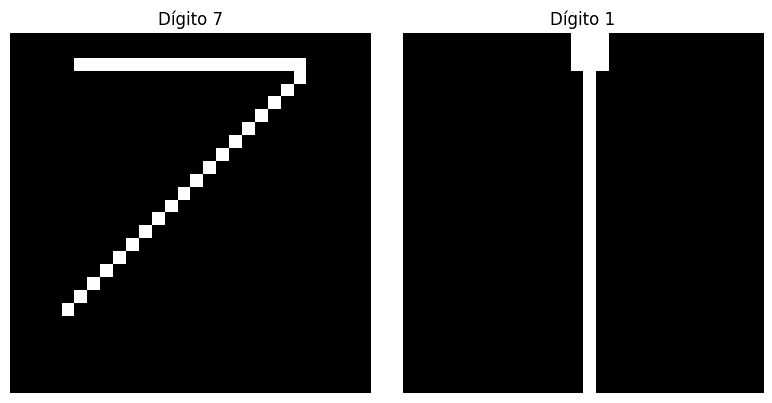

In [86]:
import matplotlib.pyplot as plt

# Crear una figura y definir dos subplots
plt.figure(figsize=(8, 4))

# Visualizar el dígito 7
plt.subplot(1, 2, 1)
plt.imshow(img7, cmap='gray')
plt.title("Dígito 7")
plt.axis("off")

# Visualizar el dígito 1
plt.subplot(1, 2, 2)
plt.imshow(img1, cmap='gray')
plt.title("Dígito 1")
plt.axis("off")

# Mostrar ambas imágenes
plt.tight_layout()
plt.show()
